# **Spatial Exploratory Analysis of mental health related instances in Police Data**

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import folium
from folium.plugins import TimestampedGeoJson
from branca.colormap import linear

import geopandas as gpd
import plotly.graph_objs as go
import json

import warnings

warnings.filterwarnings("ignore")

In [2]:
sns.set(rc={'figure.figsize':(11, 4)})

In [123]:
df_import = pd.read_csv('BD_Policedata_2017_22_all.csv')
df_import = df_import.drop(df_import.columns[0],axis=1)

In [124]:
df = df_import.copy()
df['incident_start_date'] =pd.to_datetime(df['incident_start_date'])
df['incident_end_date'] =pd.to_datetime(df['incident_end_date'])

In [125]:
df_lsoa = gpd.read_file('LSOA_2011.geojson')
df_lsoa_bradford = df_lsoa[df_lsoa.LSOA11NM.str.contains("Bradford")]

<Axes: >

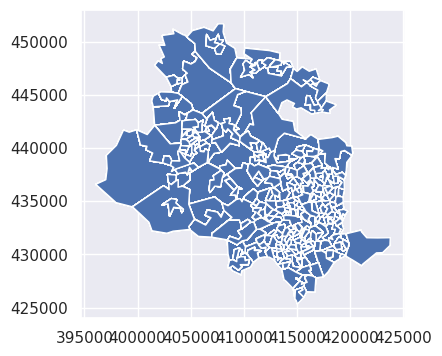

In [126]:
merged_df = pd.merge(df_lsoa_bradford, df, how='inner', left_on='LSOA11CD', right_on='lsoa')
merged_df.plot()

In [127]:
df[~df.lsoa.isin(df_lsoa_bradford.LSOA11CD.unique())].lsoa_name.unique()

array([], dtype=object)


**Bradford 030C** divided to form two LSOAs **Bradford 030E** and **Bradford 030F** in 2021. **Bradford 044B** divided to form two LSOAs **Bradford 044G** and **Bradford 044H** in 2021.

In [128]:
# Get unique LSOAs and years
all_lsoas = merged_df['LSOA11CD'].unique()
all_years = merged_df['incident_start_year'].unique()

# Create full index (Cartesian product)
full_index = pd.MultiIndex.from_product([all_lsoas, all_years], names=['LSOA11CD', 'incident_start_year'])

merged_df_grouped = merged_df.groupby(['LSOA11CD','incident_start_year']).size()
merged_df_grouped = merged_df_grouped.reindex(full_index, fill_value=0).reset_index(name='Incident_volume')

geo_gdf = merged_df[['LSOA11CD', 'geometry']].drop_duplicates(subset='LSOA11CD')
geo_gdf = gpd.GeoDataFrame(geo_gdf, geometry='geometry')
geo_gdf = geo_gdf.to_crs(epsg=4326)
geo_gdf = geo_gdf.to_json()

In [110]:
# # min year in the dataset
# start_year = 2017
# years = sorted(merged_df_grouped['incident_start_year'].unique())
# # your color-scale
# scl = [[0.0, '#ffffff'],[0.2, '#b4a8ce'],[0.4, '#8573a9'],
#        [0.6, '#7159a3'],[0.8, '#5732a1'],[1.0, '#2c0579']] # purples

# data_slider = []
# for year in years:
#     df_segmented =  merged_df_grouped[(merged_df_grouped['incident_start_year']== year)]

#     choropleth = go.Choropleth(
#         geojson=json.loads(geo_gdf),
#         featureidkey="properties.LSOA11CD",  
#         locations=df_segmented['LSOA11CD'],
#         z=df_segmented['Incident_counts'].astype(float),
#         colorscale=scl,
#         colorbar={'title': 'Incident Counts'},
#         visible=(year == start_year)
#     )

#     data_slider.append(choropleth)

# steps = []
# for i, year in enumerate(years):
#     step = dict(
#         method='restyle',
#         args=['visible', [i == j for j in range(len(data_slider))]],
#         label=str(year)
#     )
#     steps.append(step)

# sliders = [dict(active=0, pad={"t": 1}, x=0.1,y=0.01, xanchor="left",steps=steps)]

# layout = dict(
#     title='Incident counts related to\n Mental Health Since 2017',
#     width=1200,           
#     height=700,
#     margin=dict(t=0, b=0, l=0, r=0),
#     geo=dict(
#         projection=dict(
#         type='mercator'),
#         fitbounds="locations",
#         showframe=False,
#         showcoastlines=False,
#         showland=True,
#         landcolor='white',
#         bgcolor='rgba(0,0,0,0)',
#     ),
#     sliders=sliders
# )

# fig = go.Figure(data=data_slider, layout=layout)
# fig.show()

In [129]:
merged_df_crs = merged_df.to_crs(epsg=4326)

In [130]:
# Create a base map
m = folium.Map(location=[53.848, -1.837], zoom_start=11,tiles="CartoDB positron",attr='Map tiles by CartoDB, under CC BY 3.0. Data by OpenStreetMap, under ODbL.')

# Define the color scale
color_scale = linear.RdYlGn_07.scale(merged_df_grouped['Incident_volume'].min(), merged_df_grouped['Incident_volume'].max())
color_scale.colors = color_scale.colors[::-1]

# Get unique years
years = sorted(merged_df_grouped['incident_start_year'].unique())

# Prepare data for TimestampedGeoJson
features = []
for idx,entry in merged_df_grouped.iterrows():
    year = entry["incident_start_year"]
    lsoa = entry["LSOA11CD"]
    count = entry["Incident_volume"]

    # Find the corresponding geometry in geo_gdf
    geo_gdf_json = json.loads(geo_gdf)
    geometry = next((feature["geometry"] for feature in geo_gdf_json["features"] if feature["properties"]["LSOA11CD"] == lsoa), None)

    if geometry:
        feature = {
            "type": "Feature",
            "geometry": geometry,
            "properties": {
                "time": f"{year}-01-01",
                "style": {"color": "purple", "weight": 2,'fillColor': color_scale(count),
                          'fillOpacity': 0.9},
                "icon": "circle",
                "popup": f"Year: {year}<br>LSOA: {lsoa}<br>Incident Volume: {count}",
            },
        }
        features.append(feature)


# Create TimestampedGeoJson
timestamped_geojson = TimestampedGeoJson(
    {"type": "FeatureCollection", "features": features},
    period="P1Y",
    add_last_point=True,
    auto_play=False,
    loop=False,
    max_speed=1,
    loop_button=True,
    date_options="YYYY",
    time_slider_drag_update=True,
    )

# Add TimestampedGeoJson to map
timestamped_geojson.add_to(m)

color_scale.caption = 'Incident Volume'
m.add_child(color_scale)

# Add the title
title_html = """
<div style="position: fixed; top: 10px; left: 28%; transform: translateX(-50%); width: 800px; background-color: transparent;
            border:2px solid grey; z-index:9999; font-family: 'Georgia'; font-size: 20px; padding: 10px; text-align: center;">
    <b>Incident Volume for All Incident Types from 2017 to 2022</b>
</div>

"""
m.get_root().html.add_child(folium.Element(title_html))

In [131]:
m

In [138]:
m.save('Incident_volume_spatial.html')

In [132]:
merged_df_crime = merged_df[merged_df.CrimeTag=="Crime"]
merged_df_noncrime = merged_df[merged_df.CrimeTag=="Non-Crime"]

In [133]:
# Get unique LSOAs and years
all_lsoas = merged_df_crime['LSOA11CD'].unique()
all_years = merged_df_crime['incident_start_year'].unique()

# Create full index (Cartesian product)
full_index = pd.MultiIndex.from_product([all_lsoas, all_years], names=['LSOA11CD', 'incident_start_year'])

merged_df_grouped_crime = merged_df_crime.groupby(['LSOA11CD','incident_start_year']).size()
merged_df_grouped_crime = merged_df_grouped_crime.reindex(full_index, fill_value=0).reset_index(name='Incident_counts')

geo_gdf_crime = merged_df_crime[['LSOA11CD', 'geometry']].drop_duplicates(subset='LSOA11CD')
geo_gdf_crime = gpd.GeoDataFrame(geo_gdf_crime, geometry='geometry')
geo_gdf_crime = geo_gdf_crime.to_crs(epsg=4326)
geo_gdf_crime = geo_gdf_crime.to_json()

In [134]:
# Create a base map
m1 = folium.Map(location=[53.848, -1.837], zoom_start=11,tiles="CartoDB positron",attr='Map tiles by CartoDB, under CC BY 3.0. Data by OpenStreetMap, under ODbL.')

# Define the color scale
color_scale = linear.RdYlGn_07.scale(merged_df_grouped_crime['Incident_counts'].min(), merged_df_grouped_crime['Incident_counts'].max())
color_scale.colors = color_scale.colors[::-1]

# Get unique years
years = sorted(merged_df_grouped_crime['incident_start_year'].unique())

# Prepare data for TimestampedGeoJson
features = []
for idx,entry in merged_df_grouped_crime.iterrows():
    year = entry["incident_start_year"]
    lsoa = entry["LSOA11CD"]
    count = entry["Incident_counts"]

    # Find the corresponding geometry in geo_gdf
    geo_gdf_json = json.loads(geo_gdf_crime)
    geometry = next((feature["geometry"] for feature in geo_gdf_json["features"] if feature["properties"]["LSOA11CD"] == lsoa), None)

    if geometry:
        feature = {
            "type": "Feature",
            "geometry": geometry,
            "properties": {
                "time": f"{year}-01-01",
                "style": {"color": "purple", "weight": 2,'fillColor': color_scale(count),
                          'fillOpacity': 0.9},
                "icon": "circle",
                "popup": f"Year: {year}<br>LSOA: {lsoa}<br>Incident Counts: {count}",
            },
        }
        features.append(feature)


# Create TimestampedGeoJson
timestamped_geojson = TimestampedGeoJson(
    {"type": "FeatureCollection", "features": features},
    period="P1Y",
    add_last_point=True,
    auto_play=False,
    loop=False,
    max_speed=1,
    loop_button=True,
    date_options="YYYY",
    time_slider_drag_update=True,
    )

# Add TimestampedGeoJson to map
timestamped_geojson.add_to(m1)

color_scale.caption = 'Incident Volume'
m1.add_child(color_scale)


# Add the title
title_html = """
<div style="position: fixed; top: 10px; left: 28%; transform: translateX(-50%); width: 800px; background-color: transparent;
            border:2px solid grey; z-index:9999; font-family: 'Georgia'; font-size: 20px; padding: 10px; text-align: center;">
    <b>Incident Volume for Crime Incident Types from 2017 to 2022</b>
</div>

"""
m1.get_root().html.add_child(folium.Element(title_html))

In [135]:
m1

In [140]:
m1.save('Incident_volume_spatial_crime.html')

In [136]:
# Get unique LSOAs and years
all_lsoas = merged_df_noncrime['LSOA11CD'].unique()
all_years = merged_df_noncrime['incident_start_year'].unique()

# Create full index (Cartesian product)
full_index = pd.MultiIndex.from_product([all_lsoas, all_years], names=['LSOA11CD', 'incident_start_year'])

merged_df_grouped_noncrime = merged_df_noncrime.groupby(['LSOA11CD','incident_start_year']).size()
merged_df_grouped_noncrime = merged_df_grouped_noncrime.reindex(full_index, fill_value=0).reset_index(name='Incident_counts')

geo_gdf_noncrime = merged_df_noncrime[['LSOA11CD', 'geometry']].drop_duplicates(subset='LSOA11CD')
geo_gdf_noncrime = gpd.GeoDataFrame(geo_gdf_noncrime, geometry='geometry')
geo_gdf_noncrime = geo_gdf_noncrime.to_crs(epsg=4326)
geo_gdf_noncrime = geo_gdf_noncrime.to_json()

In [137]:
# Create a base map
m2 = folium.Map(location=[53.848, -1.837], zoom_start=11,tiles="CartoDB positron",attr='Map tiles by CartoDB, under CC BY 3.0. Data by OpenStreetMap, under ODbL.')

# Define the color scale
color_scale = linear.RdYlGn_07.scale(merged_df_grouped_noncrime['Incident_counts'].min(), merged_df_grouped_noncrime['Incident_counts'].max())
color_scale.colors = color_scale.colors[::-1]

# Get unique years
years = sorted(merged_df_grouped_noncrime['incident_start_year'].unique())

# Prepare data for TimestampedGeoJson
features = []
for idx,entry in merged_df_grouped_noncrime.iterrows():
    year = entry["incident_start_year"]
    lsoa = entry["LSOA11CD"]
    count = entry["Incident_counts"]

    # Find the corresponding geometry in geo_gdf
    geo_gdf_json = json.loads(geo_gdf_noncrime)
    geometry = next((feature["geometry"] for feature in geo_gdf_json["features"] if feature["properties"]["LSOA11CD"] == lsoa), None)

    if geometry:
        feature = {
            "type": "Feature",
            "geometry": geometry,
            "properties": {
                "time": f"{year}-01-01",
                "style": {"color": "purple", "weight": 2,'fillColor': color_scale(count),
                          'fillOpacity': 0.9},
                "icon": "circle",
                "popup": f"Year: {year}<br>LSOA: {lsoa}<br>Incident Counts: {count}",
            },
        }
        features.append(feature)


# Create TimestampedGeoJson
timestamped_geojson = TimestampedGeoJson(
    {"type": "FeatureCollection", "features": features},
    period="P1Y",
    add_last_point=True,
    auto_play=False,
    loop=False,
    max_speed=1,
    loop_button=True,
    date_options="YYYY",
    time_slider_drag_update=True,
    )

# Add TimestampedGeoJson to map
timestamped_geojson.add_to(m2)

color_scale.caption = 'Incident Volume'
m2.add_child(color_scale)


# Add the title
title_html = """
<div style="position: fixed; top: 10px; left: 28%; transform: translateX(-50%); width: 800px; background-color: transparent;
            border:2px solid grey; z-index:9999; font-family: 'Georgia'; font-size: 20px; padding: 10px; text-align: center;">
    <b>Incident Volume for Non-Crime Incident Types from 2017 to 2022</b>
</div>

"""
m2.get_root().html.add_child(folium.Element(title_html))

In [138]:
m2

In [144]:
m2.save('Incident_volume_spatial_noncrime.html')

In [152]:
merged_df.columns

Index(['FID', 'LSOA11CD', 'LSOA11NM', 'LSOA11NMW', 'BNG_E', 'BNG_N', 'LONG',
       'LAT', 'GlobalID', 'geometry', 'lsoa_name1', 'Index', 'lsoa1', 'lsoa',
       'incident_ref', 'reswodep', 'initial_grade', 'attended',
       'incident_sub_type', 'disposition_1_code', 'qualifiers', 'final_grade',
       'incident_end_date', 'cb_date_added', 'incident_type', 'lsoa_name',
       'incident_start_date', 'postcode_district', 'incident_id',
       'incident_duration', 'is_duplicate', 'incident_start_year',
       'incident_start_month', 'incident_start_day_num', 'incident_start_day',
       'incident_start_hour', 'incident_end_year', 'incident_end_month',
       'incident_end_day_num', 'incident_end_day', 'incident_end_hour',
       'Date_agg', 'YearTrunk', 'CrimeTag'],
      dtype='object')

In [153]:
# Create dataframe to identify incident volume per lSOA per year
crime_noncrime_lsoa = merged_df.groupby(['LSOA11NM','YearTrunk','CrimeTag']).size().reset_index(name='Incident_volume')

crime_noncrime_lsoa_pivot = crime_noncrime_lsoa.pivot_table(values='Incident_volume',index='LSOA11NM',columns=['YearTrunk','CrimeTag'],aggfunc='sum', fill_value=0)

In [154]:
# Sorting the dataframe based on Crime related incidents
crime_columns = crime_noncrime_lsoa_pivot.columns[crime_noncrime_lsoa_pivot.columns.get_level_values('CrimeTag') == 'Crime']
crime_sum = crime_noncrime_lsoa_pivot[crime_columns].sum(axis=1)
crime_noncrime_lsoa_pivot.loc[crime_sum.sort_values(ascending=False).nsmallest(10).index]

YearTrunk     17-18           18-19           19-20           20-21            \
CrimeTag      Crime Non-Crime Crime Non-Crime Crime Non-Crime Crime Non-Crime   
LSOA11NM                                                                        
Bradford 058B     0         1     0         1     0         4     0         0   
Bradford 005B     0         0     0         0     0         4     0         2   
Bradford 023E     0         6     0         0     0         3     0         5   
Bradford 003D     0         2     0         0     0         5     0         0   
Bradford 014D     0         0     0         1     0         2     0         0   
Bradford 002B     0         1     0         2     0         1     0         1   
Bradford 013B     0         5     0         3     0         8     0         1   
Bradford 023D     0         1     0         1     0         0     0         5   
Bradford 043D     1         0     0         2     0         3     0         3   
Bradford 032C     0         3     1         1     0         2     0         4   

YearTrunk     21-22            
CrimeTag      Crime Non-Crime  
LSOA11NM                       
Bradford 058B     0         1  
Bradford 005B     0         3  
Bradford 023E     0         5  
Bradford 003D     0         0  
Bradford 014D     0         0  
Bradford 002B     0         1  
Bradford 013B     0         3  
Bradford 023D     1         3  
Bradford 043D     0         1  
Bradford 032C     0         1

In [155]:
# Sorting the dataframe based on Non-Crime related incidents
non_crime_columns = crime_noncrime_lsoa_pivot.columns[crime_noncrime_lsoa_pivot.columns.get_level_values('CrimeTag') == 'Non-Crime']
non_crime_sum = crime_noncrime_lsoa_pivot[non_crime_columns].sum(axis=1)
crime_noncrime_lsoa_pivot.loc[non_crime_sum.sort_values(ascending=False).nlargest(10).index]

YearTrunk     17-18           18-19           19-20           20-21            \
CrimeTag      Crime Non-Crime Crime Non-Crime Crime Non-Crime Crime Non-Crime   
LSOA11NM                                                                        
Bradford 030D    42        82    67       133    46        97    43        94   
Bradford 037B    10        62    20       100    21       154    19        89   
Bradford 044A     5        45     8        72    19        90    24       133   
Bradford 039G    14        70    22        73    26       136    15        81   
Bradford 052D     2        29     3       134     5        80     3        82   
Bradford 020B     0        36     8        46    11       100    13       102   
Bradford 039H    26       127    20        60    17        69    14        43   
Bradford 020E     8        36     2        33    10       130    14        85   
Bradford 004H    10        51    14        71    15        69    19        76   
Bradford 008G     4        67    18        66    20        67    16        59   

YearTrunk     21-22            
CrimeTag      Crime Non-Crime  
LSOA11NM                       
Bradford 030D    31       104  
Bradford 037B    14       101  
Bradford 044A    24       125  
Bradford 039G    21       100  
Bradford 052D     5        32  
Bradford 020B     9        63  
Bradford 039H    12        46  
Bradford 020E     7        58  
Bradford 004H    13        52  
Bradford 008G    19        53

In [156]:
# Sorting the dataframe based on all incidents
crime_non_crime_sum = crime_noncrime_lsoa_pivot.sum(axis=1)
crime_noncrime_bottom10 = crime_noncrime_lsoa_pivot.loc[crime_non_crime_sum.sort_values(ascending=False).nsmallest(10).index]
crime_noncrime_top10 = crime_noncrime_lsoa_pivot.loc[crime_non_crime_sum.sort_values(ascending=False).nlargest(10).index]

In [157]:
crime_noncrime_bottom10 = crime_noncrime_bottom10.reset_index().rename(columns={'index':'LSOA11NM'})
merged_df_plot = df_lsoa_bradford[['LSOA11NM','geometry']]
merged_df_plot.columns = pd.MultiIndex.from_product([merged_df_plot.columns, ['']])
crime_noncrime_bottom10_geo = crime_noncrime_bottom10.merge(merged_df_plot,on='LSOA11NM')

<Axes: >

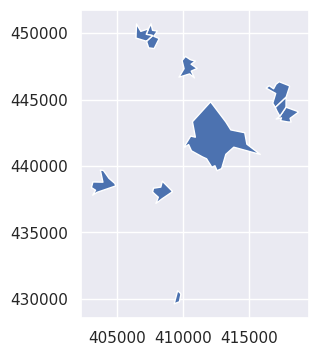

In [158]:
crime_noncrime_bottom10_geo = gpd.GeoDataFrame(crime_noncrime_bottom10_geo,geometry=crime_noncrime_bottom10_geo['geometry'])
crime_noncrime_bottom10_geo.plot()

<Axes: >

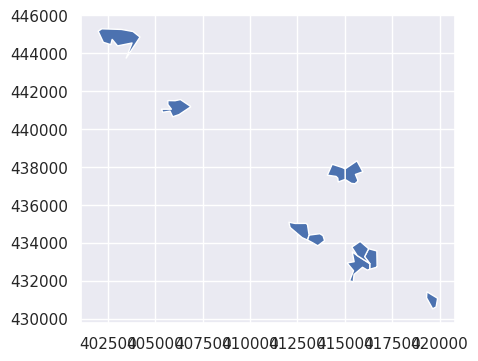

In [159]:
crime_noncrime_top10_geo = crime_noncrime_top10.merge(merged_df_plot,on='LSOA11NM')
crime_noncrime_top10_geo = gpd.GeoDataFrame(crime_noncrime_top10_geo,geometry=crime_noncrime_top10_geo['geometry'])
crime_noncrime_top10_geo.plot()

In [160]:
crime_noncrime_lsoa_pivot_sort = crime_noncrime_lsoa_pivot.loc[crime_non_crime_sum.sort_values(ascending=False).index]
crime_cumsum_prop = crime_noncrime_lsoa_pivot_sort.loc[:, crime_noncrime_lsoa_pivot_sort.columns.get_level_values(1) == 'Crime'].cumsum(axis=0)/crime_noncrime_lsoa_pivot_sort.loc[:, crime_noncrime_lsoa_pivot_sort.columns.get_level_values(1) == 'Crime'].sum(axis=0)
noncrime_cumsum_prop = crime_noncrime_lsoa_pivot_sort.loc[:, crime_noncrime_lsoa_pivot_sort.columns.get_level_values(1) == 'Non-Crime'].cumsum(axis=0)/crime_noncrime_lsoa_pivot_sort.loc[:, crime_noncrime_lsoa_pivot_sort.columns.get_level_values(1) == 'Non-Crime'].sum(axis=0)

In [162]:
noncrime_cumsum_prop[noncrime_cumsum_prop[('17-18','Non-Crime')]<=0.8]

YearTrunk,17-18,18-19,19-20,20-21,21-22
CrimeTag,Non-Crime,Non-Crime,Non-Crime,Non-Crime,Non-Crime
LSOA11NM,,,,,
Bradford 030D,0.026198,0.032962,0.022495,0.021403,0.026322
Bradford 037B,0.046006,0.057745,0.058210,0.041667,0.051886
Bradford 039G,0.068371,0.075836,0.089750,0.060109,0.077196
Bradford 044A,0.082748,0.093680,0.110622,0.090392,0.108833
Bradford 039H,0.123323,0.108550,0.126623,0.100182,0.120476
...,...,...,...,...,...
Bradford 004C,0.792013,0.801983,0.808442,0.796903,0.790686
Bradford 004E,0.794249,0.807683,0.809833,0.798042,0.792205


In [163]:
crime_cumsum_prop[crime_cumsum_prop[('17-18','Crime')]<=0.95]

YearTrunk,17-18,18-19,19-20,20-21,21-22
CrimeTag,Crime,Crime,Crime,Crime,Crime
LSOA11NM,,,,,
Bradford 030D,0.061584,0.068789,0.046138,0.040112,0.035108
Bradford 037B,0.076246,0.089322,0.067202,0.057836,0.050963
Bradford 039G,0.096774,0.111910,0.093280,0.071828,0.074745
Bradford 044A,0.104106,0.120123,0.112337,0.094216,0.101925
Bradford 039H,0.142229,0.140657,0.129388,0.107276,0.115515
...,...,...,...,...,...
Bradford 040D,0.944282,0.942505,0.935807,0.920709,0.919592
Bradford 049H,0.944282,0.942505,0.935807,0.922575,0.919592


In [164]:
# Sum across all incidents per LSOA
total_incidents_per_lsoa = crime_noncrime_lsoa_pivot.sum(axis=1)
total_crime_per_lsoa = crime_noncrime_lsoa_pivot.loc[:,crime_noncrime_lsoa_pivot.columns.get_level_values(1) == 'Crime'].sum(axis=1)
total_noncrime_per_lsoa = crime_noncrime_lsoa_pivot.loc[:,crime_noncrime_lsoa_pivot.columns.get_level_values(1) == 'Non-Crime'].sum(axis=1)

In [165]:
def gini(array):
    array = np.array(array)
    # Make sure all values are non-negative
    array = array[array >= 0]
    array = np.sort(array)
    n = array.size
    cumvals = np.cumsum(array)
    gini_coef = (n + 1 - 2 * np.sum(cumvals) / cumvals[-1]) / n
    return gini_coef

gini_value = gini(total_incidents_per_lsoa)
gini_value_crime =gini(total_crime_per_lsoa)
gini_value_noncrime = gini(total_noncrime_per_lsoa)

print(f"Gini coefficient for total incidents per LSOA: {gini_value:.4f}")
print(f"Gini coefficient for total crime incidents per LSOA: {gini_value_crime:.4f}")
print(f"Gini coefficient for total non-crime incidents per LSOA: {gini_value_noncrime:.4f}")

Gini coefficient for total incidents per LSOA: 0.4898
Gini coefficient for total crime incidents per LSOA: 0.5244
Gini coefficient for total non-crime incidents per LSOA: 0.4905


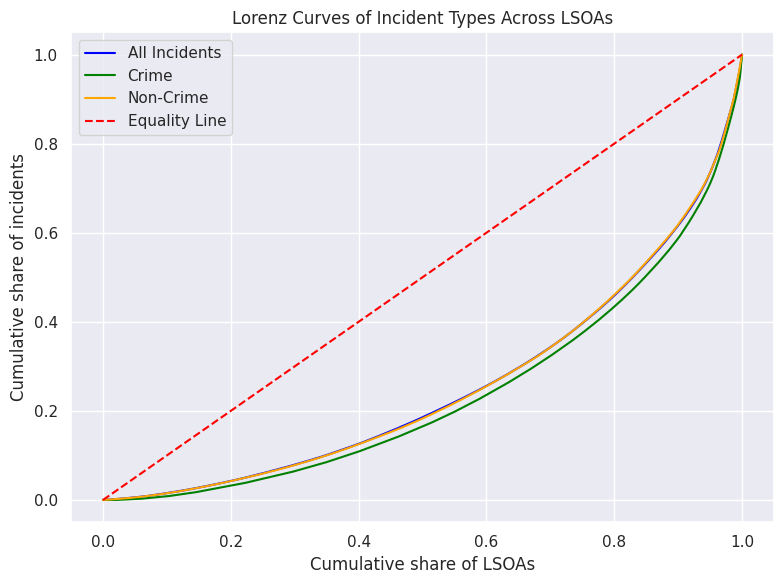

In [166]:
def plot_lorenz_curve(array):
    array = np.array(array)
    array = array[array >= 0]  
    array = np.sort(array)  # sort ascending

    cumvals = np.cumsum(array)
    total = cumvals[-1]
    cumvals = cumvals / total  # normalize to 1

    n = len(array)
    xvals = np.linspace(0, 1, n)  # cumulative share of LSOAs

    # prepend 0 for Lorenz curve starting point
    xvals = np.insert(xvals, 0, 0)
    cumvals = np.insert(cumvals, 0, 0)

    return xvals, cumvals
    
plt.figure(figsize=(8, 6))

# Plot each Lorenz curve
x1, y1 = plot_lorenz_curve(total_incidents_per_lsoa)
plt.plot(x1, y1, label='All Incidents', color='blue')

x2, y2 = plot_lorenz_curve(total_crime_per_lsoa)
plt.plot(x2, y2, label='Crime', color='green')

x3, y3 = plot_lorenz_curve(total_noncrime_per_lsoa)
plt.plot(x3, y3, label='Non-Crime', color='orange')

# Plot equality line
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Equality Line')

# Format the plot
plt.title('Lorenz Curves of Incident Types Across LSOAs')
plt.xlabel('Cumulative share of LSOAs')
plt.ylabel('Cumulative share of incidents')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [169]:
# Create dataframe to identify attended/unattended incident volume per lSOA per year
crime_attended_lsoa = merged_df.groupby(['LSOA11NM','YearTrunk','attended']).size().reset_index(name='Incident_volume')

crime_attended_lsoa_pivot = crime_attended_lsoa.pivot_table(values='Incident_volume',index='LSOA11NM',columns=['YearTrunk','attended'],aggfunc='sum', fill_value=0)

In [170]:
# Sum across all attended/unatended incidents per LSOA
total_incidents_per_lsoa = crime_attended_lsoa_pivot.sum(axis=1)
total_attended_per_lsoa = crime_attended_lsoa_pivot.loc[:,crime_attended_lsoa_pivot.columns.get_level_values(1) == True].sum(axis=1)
total_nonattended_per_lsoa = crime_attended_lsoa_pivot.loc[:,crime_attended_lsoa_pivot.columns.get_level_values(1) == False].sum(axis=1)

In [172]:
gini_value_all = gini(total_incidents_per_lsoa)
gini_value_attended =gini(total_attended_per_lsoa)
gini_value_nonattended = gini(total_nonattended_per_lsoa)

print(f"Gini coefficient for total incidents per LSOA: {gini_value_all:.4f}")
print(f"Gini coefficient for total attended incidents per LSOA: {gini_value_attended:.4f}")
print(f"Gini coefficient for total unattended incidents per LSOA: {gini_value_nonattended:.4f}")

Gini coefficient for total incidents per LSOA: 0.4898
Gini coefficient for total attended incidents per LSOA: 0.4640
Gini coefficient for total unattended incidents per LSOA: 0.5902


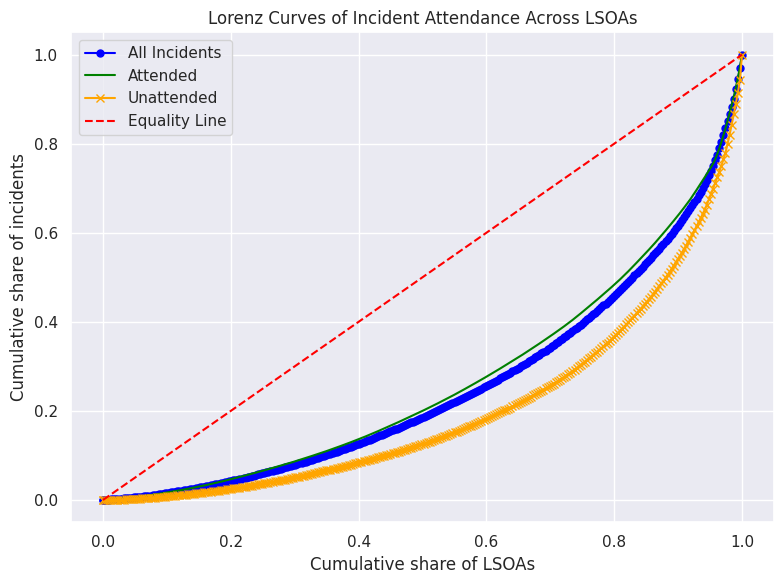

In [195]:
plt.figure(figsize=(8, 6))

# Plot each Lorenz curve
x1, y1 = plot_lorenz_curve(total_incidents_per_lsoa)
plt.plot(x1, y1, label='All Incidents', marker='o',markersize=5, color='blue')

x2, y2 = plot_lorenz_curve(total_attended_per_lsoa)
plt.plot(x2, y2, label='Attended', color='green')

x3, y3 = plot_lorenz_curve(total_nonattended_per_lsoa)
plt.plot(x3, y3, label='Unattended',marker='x',linestyle='-', color='orange')

# Plot equality line
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Equality Line')

# Format the plot
plt.title('Lorenz Curves of Incident Attendance Across LSOAs')
plt.xlabel('Cumulative share of LSOAs')
plt.ylabel('Cumulative share of incidents')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('Lorenz_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [197]:
# Create dataframe to identify incident grading per lSOA per year
crime_attended_lsoa = merged_df.groupby(['LSOA11NM','YearTrunk','final_grade']).size().reset_index(name='Incident_volume')

crime_attended_lsoa_pivot = crime_attended_lsoa.pivot_table(values='Incident_volume',index='LSOA11NM',columns=['YearTrunk','final_grade'],aggfunc='sum', fill_value=0)

In [199]:
# Sum across all attended/unatended incidents per LSOA
total_incidents_per_lsoa = crime_attended_lsoa_pivot.sum(axis=1)
total_emergency_per_lsoa = crime_attended_lsoa_pivot.loc[:,crime_attended_lsoa_pivot.columns.get_level_values(1) == 'EMERGENCY'].sum(axis=1)
total_priority_per_lsoa = crime_attended_lsoa_pivot.loc[:,crime_attended_lsoa_pivot.columns.get_level_values(1) == 'PRIORITY'].sum(axis=1)
total_standard_per_lsoa = crime_attended_lsoa_pivot.loc[:,crime_attended_lsoa_pivot.columns.get_level_values(1) == 'STANDARD'].sum(axis=1)

In [201]:
gini_value_all = gini(total_incidents_per_lsoa)
gini_value_emergency =gini(total_emergency_per_lsoa)
gini_value_priority = gini(total_priority_per_lsoa)
gini_value_standard = gini(total_standard_per_lsoa)

print(f"Gini coefficient for total incidents per LSOA: {gini_value_all:.4f}")
print(f"Gini coefficient for total emergency incidents per LSOA: {gini_value_emergency:.4f}")
print(f"Gini coefficient for total priority incidents per LSOA: {gini_value_priority:.4f}")
print(f"Gini coefficient for total standard incidents per LSOA: {gini_value_standard:.4f}")

Gini coefficient for total incidents per LSOA: 0.4898
Gini coefficient for total emergency incidents per LSOA: 0.4759
Gini coefficient for total priority incidents per LSOA: 0.4781
Gini coefficient for total standard incidents per LSOA: 0.5568


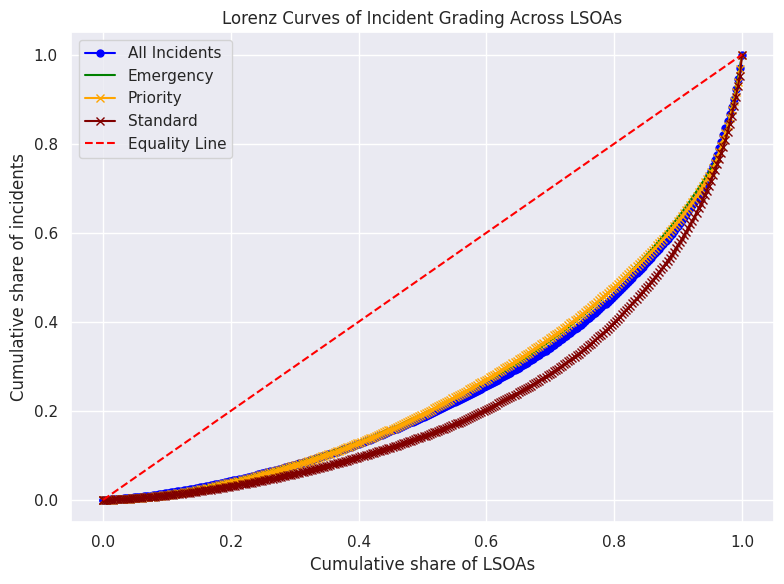

In [203]:
plt.figure(figsize=(8, 6))

# Plot each Lorenz curve
x1, y1 = plot_lorenz_curve(total_incidents_per_lsoa)
plt.plot(x1, y1, label='All Incidents', marker='o',markersize=5, color='blue')

x2, y2 = plot_lorenz_curve(total_emergency_per_lsoa)
plt.plot(x2, y2, label='Emergency', color='green')

x3, y3 = plot_lorenz_curve(total_priority_per_lsoa)
plt.plot(x3, y3, label='Priority',marker='x',linestyle='-', color='orange')

x4, y4 = plot_lorenz_curve(total_standard_per_lsoa)
plt.plot(x4, y4, label='Standard',marker='x',linestyle='-', color='maroon')

# Plot equality line
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Equality Line')

# Format the plot
plt.title('Lorenz Curves of Incident Grading Across LSOAs')
plt.xlabel('Cumulative share of LSOAs')
plt.ylabel('Cumulative share of incidents')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('Lorenz_curves_grading.png', dpi=300, bbox_inches='tight')
plt.show()